In [11]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

In [12]:
def query_gate(case : int): # Implementing all the functions and their query gate
    if case not in [1,2,3,4]:
        raise ValueError("'case' must be 1,2,3,4")
    
    f = QuantumCircuit(2)
    if case in [2,3]:
        f.cx(0,1)
    if case in [3,4]:
        f.x(1)
    return f

# q0 is x and q1 is y

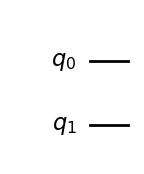

In [13]:
display(query_gate(1).draw(output="mpl"))

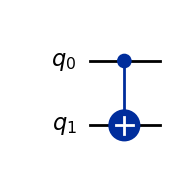

In [14]:
display(query_gate(2).draw(output="mpl"))

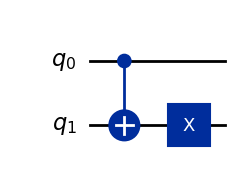

In [15]:
display(query_gate(3).draw(output="mpl"))

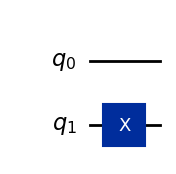

In [16]:
display(query_gate(4).draw(output="mpl"))

In [17]:
def compile_circuit(qg : QuantumCircuit):   # making the whole quantum circuit for the algorithm
    
    qc = QuantumCircuit(2, 1)

    qc.x(1)
    qc.h(range(2))

    qc.barrier()
    qc.compose(qg, inplace = True)

    qc.barrier()
    qc.h(range(1))
    qc.measure(range(1), range(1))

    return qc

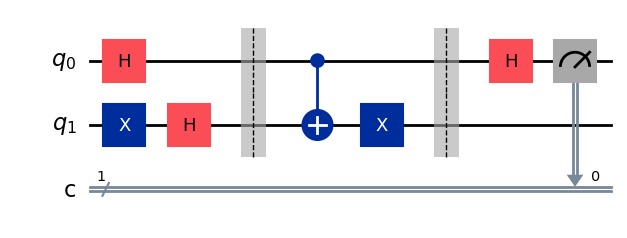

In [18]:
display(compile_circuit(query_gate(3)).draw(output="mpl"))

In [19]:
def deutsch_algorithm(function : QuantumCircuit):   # simulating the algorithm

    qc = compile_circuit(function)

    result = AerSimulator().run(qc, shots=1,memory=True).result()
    measurements = result.get_memory()  
    if measurements[0] == "0":
        return "constant"
    return "balanced"


In [20]:
f = 2
qg = query_gate(f)
print(deutsch_algorithm(qg))

balanced
